## Cat & Dog Image Classification Project (Using Transfer Learning with Pretrained Models)

To speed up training and improve performance, I will use two popular pretrained models:
1. **MobileNetV3Large**: Extremely fast and designed for mobile/edge deployment.
2. **EfficientNetB0**: Highly accurate with a scaling method that balances depth, width, and resolution.

## Importing requirements

In [1]:
import tensorflow
import numpy as np
import pandas as pd

In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!nvidia-smi

Fri Oct  9 20:13:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!cp -r "/content/drive/MyDrive/Tarun_DL/CAT-DOG" "/content/CAT-DOG"

In [7]:
import os

DATA_DIR = "/content/CAT-DOG"
train_dir = os.path.join(DATA_DIR, 'train')
test_dir = os.path.join(DATA_DIR, 'test')

for split in ['train', 'test']:
    print(split, os.listdir(f"{DATA_DIR}/{split}"))

train ['cats', '.DS_Store', 'dogs']
test ['cats', '.DS_Store', 'dogs']


### Dataset Configuration and Inspection for CAT-DOG

In [8]:
# 1. Set correct path for the Cat-Dog dataset directory
DATA_DIR = '/content/CAT-DOG'

# 2. Inspect splits and count files in each class dynamically
for split in ['train', 'test']:
    split_dir = os.path.join(DATA_DIR, split)
    if os.path.exists(split_dir):
        print(f"\n--- {split.upper()} SPLIT ---")
        for cls in os.listdir(split_dir):
            cls_dir = os.path.join(split_dir, cls)
            # Ensure we only count directories (ignoring hidden files like .DS_Store)
            if os.path.isdir(cls_dir):
                num_images = len(os.listdir(cls_dir))
                print(f"Class: {cls} -> {num_images} images")



--- TRAIN SPLIT ---
Class: cats -> 10000 images
Class: dogs -> 10016 images

--- TEST SPLIT ---
Class: cats -> 2500 images
Class: dogs -> 2500 images


## Loading Data

In [9]:
# 3. Configure Model Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print(f"\nConfigurations set: IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, SEED={SEED}")


Configurations set: IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=42


In [10]:
import os
import glob
from sklearn.model_selection import train_test_split

DATA_DIR = "/content/CAT-DOG"

cat_paths = glob.glob(os.path.join(DATA_DIR, "train", "cats", "*"))
dog_paths = glob.glob(os.path.join(DATA_DIR, "train", "dogs", "*"))

all_paths = cat_paths + dog_paths

# 0 = cats, 1 = dogs
all_labels = [0] * len(cat_paths) + [1] * len(dog_paths)

print("Total images:", len(all_paths))
print("Cats:", len(cat_paths))
print("Dogs:", len(dog_paths))

Total images: 20016
Cats: 10000
Dogs: 10016


In [11]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels,
    shuffle=True
)

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.float32)

In [13]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

train_ds = (
    train_ds
    .shuffle(len(train_paths), seed=SEED)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [14]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{DATA_DIR}/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)


Found 5000 files belonging to 2 classes.


In [ ]:
# CHECK DATASET SIZE

In [15]:
print("\nNumber of batches:")
print("Train:", train_ds.cardinality().numpy())
print("Validation:", val_ds.cardinality().numpy())
print("Test:", test_ds.cardinality().numpy())



Number of batches:
Train: 501
Validation: 126
Test: 157


## 1. MobileNetV3Large

In [16]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large

In [17]:
# 1. Load the MobileNetV3Large base model pre-trained on ImageNet
# We exclude the top classification layer and specify our input shape
base_mobilenet = MobileNetV3Large(input_shape=(224, 224, 3),
                                  include_top=False,
                                  weights='imagenet')

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
# Freeze the base model to retain learned features
base_mobilenet.trainable = False

In [20]:
# 2. Build the Model Architecture
inputs = layers.Input(shape=(224, 224, 3))

# MobileNetV3Large includes its preprocessing by default
x = base_mobilenet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128,activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1,activation='sigmoid')(x)

mobilenet_model = models.Model(inputs=inputs,outputs=outputs)

In [21]:
# 3. Compile the model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [22]:
mobilenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,119,489 (11.90 MB)

 Trainable params: 123,137 (481.00 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

## With Callback

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_loss = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

checkpoint = ModelCheckpoint(
    '/content/best_mobilenetv3large.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [31]:
# Fit the model with limited steps to train much faster

EPOCHS = 15

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_loss,
        checkpoint
    ]
)

Epoch 1/15
500/501 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9891 - auc: 0.9988 - loss: 0.0328 - precision: 0.9896 - recall: 0.9888
Epoch 1: val_loss improved from None to 0.02975, saving model to /content/best_mobilenetv3large.keras

Epoch 1: finished saving model to /content/best_mobilenetv3large.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9894 - auc: 0.9989 - loss: 0.0316 - precision: 0.9898 - recall: 0.9890 - val_accuracy: 0.9888 - val_auc: 0.9995 - val_loss: 0.0297 - val_precision: 0.9861 - val_recall: 0.9915 - learning_rate: 0.0010
Epoch 2/15
500/501 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9926 - auc: 0.9992 - loss: 0.0221 - precision: 0.9933 - recall: 0.9920
Epoch 2: val_loss did not improve from 0.02975
501/501 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9922 - auc: 0.9994 - loss: 0.0214 - precision: 0.9924 - recall: 0.9920 - val_accuracy: 0.9885 - val_auc: 0.9990 - val_loss: 0.0343 - val_precision: 0.9890 - val_recall: 0.9880 - learning_ra

In [32]:
best_epoch = np.argmin(mobilenet_history.history['val_loss']) + 1
best_val_loss = min(mobilenet_history.history['val_loss'])

best_epoch_acc = np.argmax(mobilenet_history.history['val_accuracy']) + 1
best_val_accuracy = max(mobilenet_history.history['val_accuracy'])

print("Best epoch loss:", best_epoch)
print("Best validation loss:", best_val_loss)

print("Best epoch accuracy:", best_epoch_acc)
print("Best validation accuracy:", best_val_accuracy)

Best epoch loss: 3
Best validation loss: 0.029667876660823822
Best epoch accuracy: 3
Best validation accuracy: 0.9902597665786743


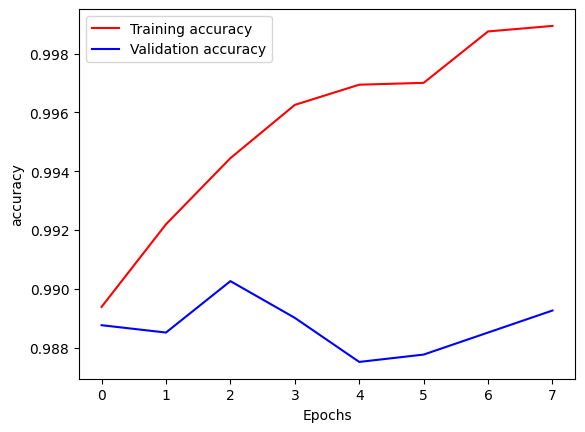

In [33]:
import matplotlib.pyplot as plt

# Plot the training and validation accuracy
plt.plot(mobilenet_history.history['accuracy'], color='red', label='Training accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], color='blue',label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

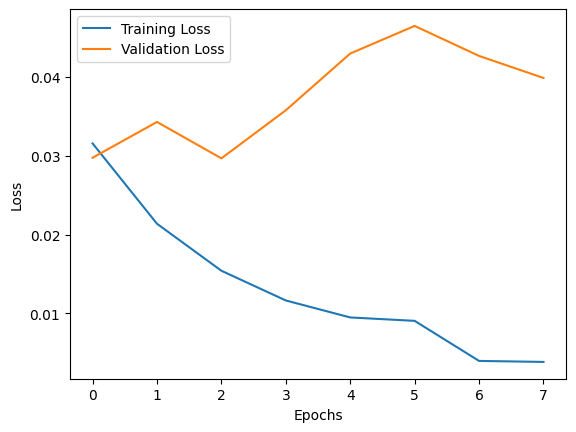

In [34]:
import matplotlib.pyplot as plt

# Plot the training and validation loss
plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [35]:
best_mobilenet = tf.keras.models.load_model(
    "/content/best_mobilenetv3large.keras"
)

In [36]:
test_results = best_mobilenet.evaluate(
    test_ds,
    return_dict=True
)

for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - accuracy: 0.9906 - auc: 0.9991 - loss: 0.0279 - precision: 0.9920 - recall: 0.9892
accuracy: 0.9906
auc: 0.9991
loss: 0.0279
precision: 0.9920
recall: 0.9892


## 2. EfficientNetB0


In [46]:
from tensorflow.keras.applications import EfficientNetB0

# 1. Load the EfficientNetB0 base model
# Note: EfficientNet models have built-in rescaling layers, but since we scale 1./255
# in train_generator, we can safely pass it as is.
base_efficientnet = EfficientNetB0(input_shape=(224, 224, 3),
                                    include_top=False,
                                    weights='imagenet')


In [47]:
# Freeze the base model
base_efficientnet.trainable = False

In [48]:
# 2. Build the Model Architecture
efficientnet_model = models.Sequential([
    base_efficientnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [49]:
# 3. Compile the model
efficientnet_model.compile(optimizer='adam',
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

In [50]:
efficientnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [51]:
# Train EfficientNetB0 with limited steps to train much faster
print("Training EfficientNetB0...")

efficientnet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_efficientnet.keras', monitor='val_accuracy', save_best_only=True)
]


Training EfficientNetB0...


In [52]:
efficientnet_history = efficientnet_model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=efficientnet_callbacks
)

Epoch 1/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 87s 116ms/step - accuracy: 0.9875 - loss: 0.0379 - val_accuracy: 0.9930 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 2/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9932 - loss: 0.0198 - val_accuracy: 0.9923 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 3/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.9950 - loss: 0.0150 - val_accuracy: 0.9918 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 4/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.9957 - loss: 0.0136 - val_accuracy: 0.9920 - val_loss: 0.0258 - learning_rate: 0.0010
Epoch 5/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9957 - loss: 0.0113 - val_accuracy: 0.9923 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 6/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9969 - loss: 0.0095 - val_accuracy: 0.9933 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 7/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9966 - 

In [53]:
best_epoch = np.argmin(efficientnet_history.history['val_loss']) + 1
best_val_loss = min(efficientnet_history.history['val_loss'])

best_epoch_acc = np.argmax(efficientnet_history.history['val_accuracy']) + 1
best_val_accuracy = max(efficientnet_history.history['val_accuracy'])

print("Best epoch loss:", best_epoch)
print("Best validation loss:", best_val_loss)

print("Best epoch accuracy:", best_epoch_acc)
print("Best validation accuracy:", best_val_accuracy)

Best epoch loss: 5
Best validation loss: 0.022601952776312828
Best epoch accuracy: 6
Best validation accuracy: 0.9932567477226257


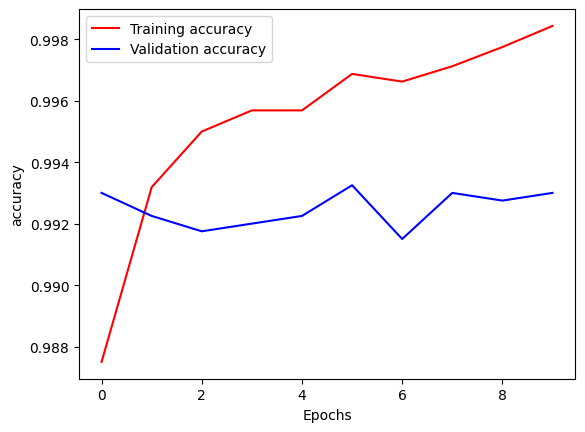

In [54]:
import matplotlib.pyplot as plt

# Plot the training and validation accuracy
plt.plot(efficientnet_history.history['accuracy'], color='red', label='Training accuracy')
plt.plot(efficientnet_history.history['val_accuracy'], color='blue',label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

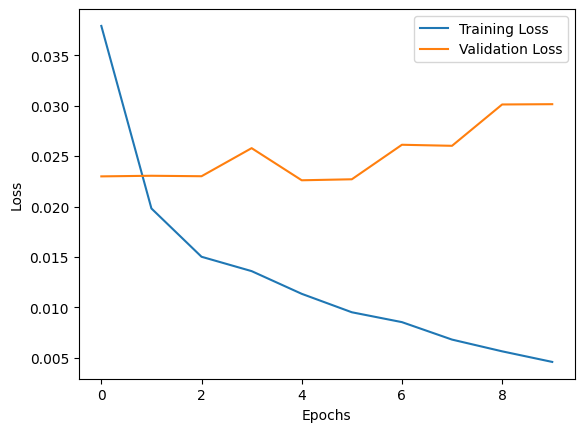

In [55]:
import matplotlib.pyplot as plt

# Plot the training and validation loss
plt.plot(efficientnet_history.history['loss'], label='Training Loss')
plt.plot(efficientnet_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [56]:
best_efficientnet = tf.keras.models.load_model(
    "/content/best_efficientnet.keras"
)

In [57]:
test_results = best_efficientnet.evaluate(
    test_ds,
    return_dict=True
)

for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 93ms/step - accuracy: 0.9916 - loss: 0.0242
accuracy: 0.9916
loss: 0.0242


157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 137ms/step
Confusion Matrix:
[[2484   16]
 [  26 2474]]

Classification Report:
              precision    recall  f1-score   support

        Cats     0.9896    0.9936    0.9916      2500
        Dogs     0.9936    0.9896    0.9916      2500

    accuracy                         0.9916      5000
   macro avg     0.9916    0.9916    0.9916      5000
weighted avg     0.9916    0.9916    0.9916      5000



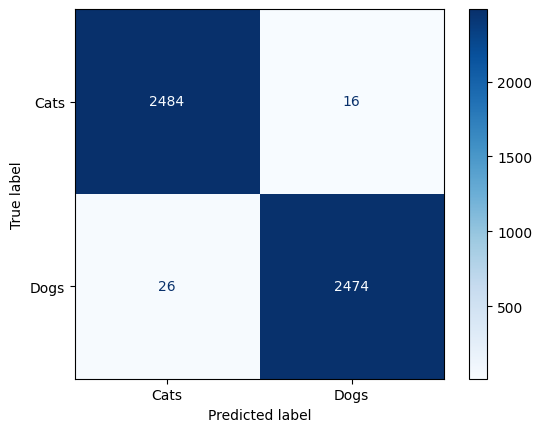

In [58]:
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay)

y_true = np.concatenate([
    labels.numpy().ravel()
    for _, labels in test_ds
]).astype(int)

y_prob = best_efficientnet.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Cats", "Dogs"],
    digits=4
))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Cats", "Dogs"],
    cmap="Blues"
)
plt.show()

## 3. Deploying Your Models in Streamlit: Saving vs. Direct Loading

When building your Streamlit application, you have two options depending on which model you choose to deploy:

#### Option A: Using the Raw Pre-trained Models (No Manual Saving Needed!)
If you choose to deploy the **raw, pre-trained ImageNet models** (which gave you **90.78%** accuracy with EfficientNetB0), you **do not need to save or download any model files**!

When your Streamlit app starts up on a machine or server, Keras automatically downloads the model weights from Google's servers. You can load it directly with a single line of code:
```python
import tensorflow as tf
model = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=True)
```

---

#### Option B: Using Your Fine-Tuned Custom Models (Saving Needed!)
If you prefer to deploy the models we fine-tuned on your custom dataset, they **must** be saved as files. Fortunately, our `ModelCheckpoint` callbacks **automatically saved them** during training!

You can find these files in your Colab file explorer on the left:
* `best_mobilenet.keras`
* `best_efficientnet.keras`

**What to do:**
1. Open the file browser in Google Colab (click the folder icon on the left panel).
2. Download `best_efficientnet.keras` to your local computer.
3. Put this file in the same folder as your Streamlit `app.py` script.
4. Load it inside your Streamlit app like this:
```python
import tensorflow as tf
model = tf.keras.models.load_model('best_efficientnet.keras')
```